### Reto Limpieza del Conjunto de Datos

Emiliano Camacho Ponce A01712408

Alfredo Alejandro Soto Herrera A01711368

Facundo Bautista Barbera A01066843

Charbel Isaías Chávez Zavala A01711950

Definimos los parámetros que gobiernan
las decisiones posteriores:

- **`tamano = (256, 256)`**: resolución objetivo a la que se reescalarán todas las
  imágenes y máscaras.
- **`clases`** y **`colores`**: nombres y paleta fijos para los 4 canales de las máscaras
  (vidrio esmerilado, consolidación, otros tejidos pulmonares, fondo).
- **`salida`** incluye un timestamp único por corrida, para no sobreescribir resultados
  de ejecuciones previas del ETL.

In [ ]:
from pathlib import Path
from datetime import datetime
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from IPython.display import display

carpeta = Path.cwd()
proyecto = carpeta if carpeta.name == "mini-reto" else carpeta / "mini-reto"
entrada = proyecto / "data" / "raw"
salida = proyecto / "data" / "processed" / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
tamano = (256, 256)
clases = ["Vidrio esmerilado", "Consolidación", "Otros tejidos pulmonares", "Fondo"]
colores = ["#f4a261", "#e63946", "#2a9d8f", "#64748b"]
pd.set_option("display.float_format", "{:,.4f}".format)


### Validación de forma e inventario

- **Decisión de limpieza:** se exige que todas las
  imágenes tengan forma `(N, 512, 512, 1)` y que, si existe archivo de máscaras, tenga
  forma `(N, 512, 512, 4)` mismo número de cortes que su imagen correspondiente.
  Si no se cumple, se detiene la ejecución con `ValueError` en lugar de intentar
  continuar con datos mal formados.
- Se usa `mmap_mode="r"` para no cargar los `.npy` completos en memoria porqie son varios GB,
  y `allow_pickle=False` para evitar deserializar objetos arbitrarios.
- Se construye el `inventario` (tamaño
  en MB, tipo de dato, dimensiones) para diagnóstico.

In [ ]:
archivos = {
    "medseg": ("images_medseg.npy", "masks_medseg.npy"),
    "radiopedia": ("images_radiopedia.npy", "masks_radiopedia.npy"),
    "prueba": ("test_images_medseg.npy", None),
}

datos = {}
inventario = []
for fuente, (archivo_imagen, archivo_mascara) in archivos.items():
    imagenes = np.load(entrada / archivo_imagen, mmap_mode="r", allow_pickle=False)
    mascaras = np.load(entrada / archivo_mascara, mmap_mode="r", allow_pickle=False) if archivo_mascara else None
    if imagenes.ndim != 4 or imagenes.shape[1:] != (512, 512, 1):
        raise ValueError(f"Forma inesperada en {archivo_imagen}: {imagenes.shape}")
    if mascaras is not None and mascaras.shape != (*imagenes.shape[:3], 4):
        raise ValueError(f"Las imágenes y máscaras de {fuente} no coinciden")
    datos[fuente] = (imagenes, mascaras)
    for nombre, arreglo in [(archivo_imagen, imagenes), (archivo_mascara, mascaras)]:
        if arreglo is not None:
            inventario.append({"archivo": nombre, "dimensiones": str(arreglo.shape),
                               "tipo": str(arreglo.dtype), "MB": arreglo.nbytes / 1e6})
inventario = pd.DataFrame(inventario)
display(inventario)


,archivo,dimensiones,tipo,MB
0,images_medseg.npy,"(100, 512, 512, 1)",float64,209.7152
1,masks_medseg.npy,"(100, 512, 512, 4)",bool,104.8576
2,images_radiopedia.npy,"(829, 512, 512, 1)",float64,"1,738.5390"
3,masks_radiopedia.npy,"(829, 512, 512, 4)",bool,869.2695
4,test_images_medseg.npy,"(10, 512, 512, 1)",float64,20.9715


### Revisamos atributo por atributo

Aquí se calculan por cada corte individual los atributos que luego deciden qué se
conserva y qué se revisa:

- **`imagen_finita`**: `True` solo si todos los píxeles son finitos (`np.isfinite`).
  Los estadísticos (`minimo`, `maximo`, `media`, `desviacion`) se dejan en `NaN` si la
  imagen no es finita.
- **`huella_imagen`**: permite detectar duplicados
  exactos más adelante, comparando huellas en vez de arreglos completos.
- **`imagen_constante`**: se marca cuando `minimo == maximo`, es decir, un corte sin
  ningún contraste (imagen inútil para segmentación).
- **Validez de máscara** (`mascara_valida`): una máscara se considera válida solo si
  (a) todos sus valores son estrictamente 0 o 1, y (b) la suma de los 3 canales de
  lesión (vidrio esmerilado, consolidación, otros tejidos) por píxel es ≤ 1. Un
  píxel no puede pertenecer a más de una clase de lesión a la vez. El canal de fondo se excluye deliberadamente de esta regla de exclusividad porque se sabe
  que puede venir inconsistente con las otras tres clases.
- **`pixeles_fondo_inconsistente`**: cuenta cuántos píxeles del canal de fondo original
  no coinciden con el complemento lógico de las otras tres clases. Esta inconsistencia **no** provoca
  descarte aquí; solo se documenta. La corrección real ocurre después, donde el canal de fondo se recalcula por completo.
- **`proporcion_lesion`**: suma de las proporciones de las clases 0 y 1 (vidrio
  esmerilado + consolidación), usada como métrica resumen de "cuánta lesión" tiene
  cada corte.

In [ ]:
registros = []
for fuente, (imagenes, mascaras) in datos.items():
    for indice in range(len(imagenes)):
        imagen = imagenes[indice, ..., 0]
        finita = bool(np.isfinite(imagen).all())
        registro = {
            "id": f"{fuente}_{indice:04d}", "fuente": fuente, "indice": indice,
            "imagen_finita": finita,
            "minimo": float(imagen.min()) if finita else np.nan,
            "maximo": float(imagen.max()) if finita else np.nan,
            "media": float(imagen.mean()) if finita else np.nan,
            "desviacion": float(imagen.std()) if finita else np.nan,
            "huella_imagen": hashlib.sha256(imagen.tobytes()).hexdigest(),
            "huella_mascara": None, "mascara_valida": None, "pixeles_fondo_inconsistente": 0,
        }
        for clase in range(4):
            registro[f"proporcion_{clase}"] = np.nan
        if mascaras is not None:
            mascara = mascaras[indice]
            valida = bool(np.isin(mascara, [0, 1]).all() and (mascara[..., :3].sum(axis=-1) <= 1).all())
            fondo_esperado = ~mascara[..., :3].any(axis=-1)
            registro["pixeles_fondo_inconsistente"] = int((mascara[..., 3] != fondo_esperado).sum())
            registro["mascara_valida"] = valida
            registro["huella_mascara"] = hashlib.sha256(mascara.tobytes()).hexdigest()
            if valida:
                for clase in range(4):
                    registro[f"proporcion_{clase}"] = float(mascara[..., clase].mean())
        registros.append(registro)

auditoria = pd.DataFrame(registros)
auditoria["proporcion_lesion"] = auditoria.proporcion_0 + auditoria.proporcion_1
auditoria["imagen_constante"] = auditoria.minimo == auditoria.maximo
display(auditoria.head())
display(auditoria.groupby("fuente")[["minimo", "maximo", "media", "desviacion"]].agg(["min", "median", "max"]).rename(
    columns={"min": "mínimo", "median": "mediana", "max": "máximo"}))
display(pd.Series({
    "Imágenes no finitas": int((~auditoria.imagen_finita).sum()),
    "Imágenes constantes": int(auditoria.imagen_constante.sum()),
    "Máscaras inválidas": int((auditoria.mascara_valida == False).sum()),
    "Máscaras con fondo inconsistente": int((auditoria.pixeles_fondo_inconsistente > 0).sum()),
    "Imágenes repetidas adicionales": int(auditoria.huella_imagen.duplicated().sum()),
}, name="Cantidad"))


,id,fuente,indice,imagen_finita,minimo,maximo,media,desviacion,huella_imagen,huella_mascara,mascara_valida,pixeles_fondo_inconsistente,proporcion_0,proporcion_1,proporcion_2,proporcion_3,proporcion_lesion,imagen_constante
0,medseg_0000,medseg,0,True,"-1,414.8936",212.7660,-627.1349,575.8760,c617bfb0f85dc5f4b22023aab18fa54d90b323ada259f5...,ad5987b6a0018de8f227b3ec43e3b9553b1f174c95c726...,True,0,0.0310,0.1055,0.0207,0.8428,0.1365,False
1,medseg_0001,medseg,1,True,"-1,477.6923",278.5918,-528.5524,461.9249,2e4d85e6b55306685e2c3f84ad3a114fade1da1e46f696...,737bac85304236487300760b15e1e55dd404c522ffe2e3...,True,0,0.0763,0.1430,0.1465,0.6342,0.2193,False
2,medseg_0002,medseg,2,True,"-1,070.7746",272.2490,-550.2367,462.7275,af14838d15a6f416c599ece845bf5f64d7e84ada5a19a5...,57ee6a53d42b56c889e27018aee571b04f74c8e3052bd4...,True,0,0.0031,0.0000,0.2121,0.7848,0.0031,False
3,medseg_0003,medseg,3,True,"-1,146.9388",267.3469,-576.8326,474.6491,6e450f532a9d18c35291240332d6aef10722df73350098...,aa964e1cbb83232a4a3068f2dbc3427a08dbb2696b3fc2...,True,0,0.0387,0.0230,0.0846,0.8537,0.0617,False
4,medseg_0004,medseg,4,True,"-1,061.5379",262.0646,-348.6632,402.1301,f69f1e777ca706b8cf89774315eeda3b6f7cb838074a46...,e286ce61788bb027b5c6eb7b8656e3b0c857a921f2b59f...,True,0,0.0248,0.0000,0.4337,0.5415,0.0248,False


minimo                           maximo                    \
                mínimo     mediana      máximo   mínimo  mediana   máximo   
fuente                                                                      
medseg     -1,606.5217 -1,202.6395   -999.0604  14.3344 252.8176 597.8047   
prueba     -1,450.0000 -1,206.6631 -1,037.6594 177.8523 302.1923 875.6456   
radiopedia -1,414.7654 -1,334.5728 -1,151.7725 136.5284 136.5284 291.0408   

                 media                     desviacion                    
                mínimo   mediana    máximo     mínimo  mediana   máximo  
fuente                                                                   
medseg     -1,021.4200 -412.8645 -123.8465   217.4706 455.8552 604.8113  
prueba       -704.4954 -372.2518 -160.2301   399.1624 465.7566 574.6290  
radiopedia   -649.9664 -474.9098 -105.6649   339.6310 486.5277 534.9848

Imágenes no finitas                   0
Imágenes constantes                   0
Máscaras inválidas                    0
Máscaras con fondo inconsistente    279
Imágenes repetidas adicionales        0
Name: Cantidad, dtype: int64

### Visualización exploratoria

Graficamos las distribuciones (cortes por fuente, intensidad media, cobertura
de lesión) a partir de los atributos calculados en la celda anterior.

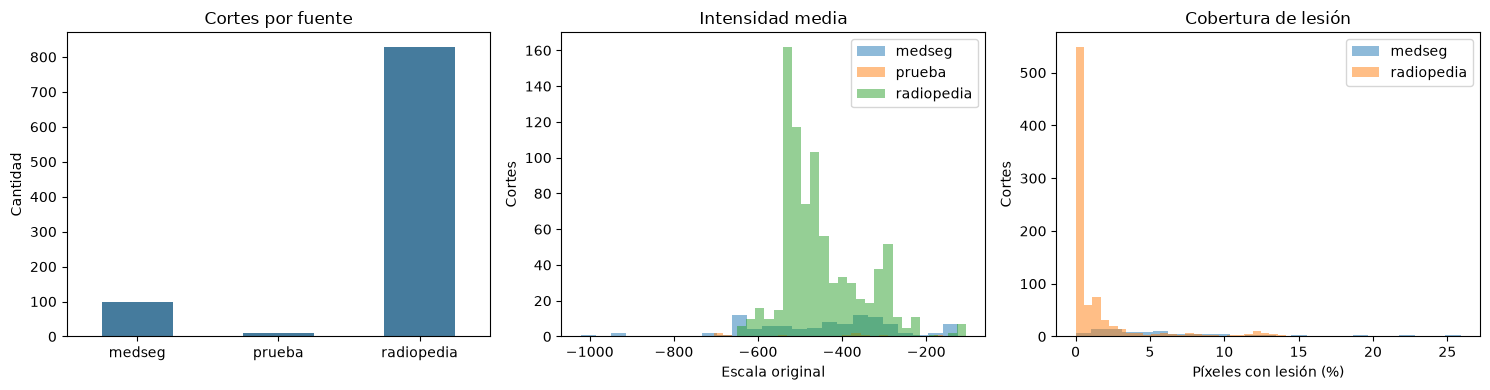

In [ ]:
figura, ejes = plt.subplots(1, 3, figsize=(15, 4))
auditoria.groupby("fuente").size().plot.bar(ax=ejes[0], color="#457b9d", rot=0)
ejes[0].set(title="Cortes por fuente", xlabel="", ylabel="Cantidad")
for fuente, grupo in auditoria.groupby("fuente"):
    ejes[1].hist(grupo.media.dropna(), bins=25, alpha=0.5, label=fuente)
    if fuente != "prueba":
        ejes[2].hist(grupo.proporcion_lesion.dropna() * 100, bins=25, alpha=0.5, label=fuente)
ejes[1].set(title="Intensidad media", xlabel="Escala original", ylabel="Cortes")
ejes[2].set(title="Cobertura de lesión", xlabel="Píxeles con lesión (%)", ylabel="Cortes")
ejes[1].legend()
ejes[2].legend()
plt.tight_layout()
plt.show()


### Balance de clases

Se calcula el porcentaje de píxeles por clase, usando únicamente los cortes con
`mascara_valida == True` (`mascaras_validas`). Simplemente es un chequeo de balance de clases.

,Vidrio esmerilado,Consolidación,Otros tejidos pulmonares,Fondo
fuente,,,,
medseg,4.5641,2.2477,19.9857,73.2044
radiopedia,1.0211,0.2284,14.4977,84.2630


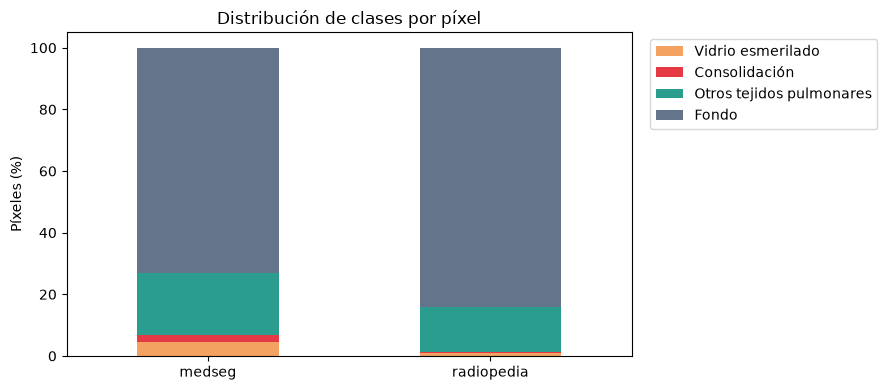

,cortes,sin_lesion,cobertura_mediana
fuente,,,
medseg,100,1,0.0473
radiopedia,829,457,0.0000


In [ ]:
mascaras_validas = auditoria[auditoria.mascara_valida == True]
columnas_clase = [f"proporcion_{clase}" for clase in range(4)]
balance_clases = mascaras_validas.groupby("fuente")[columnas_clase].mean() * 100
balance_clases.columns = clases
display(balance_clases)
balance_clases.plot.bar(stacked=True, color=colores, figsize=(9, 4), rot=0)
plt.title("Distribución de clases por píxel")
plt.ylabel("Píxeles (%)")
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
display(mascaras_validas.groupby("fuente").agg(
    cortes=("id", "size"),
    sin_lesion=("proporcion_lesion", lambda valores: int((valores == 0).sum())),
    cobertura_mediana=("proporcion_lesion", "median"),
))


### Inspección visual de muestras

Se seleccionan cortes representativos (mínima, mediana y máxima proporción de lesión
por fuente) solo para su inspección visual.

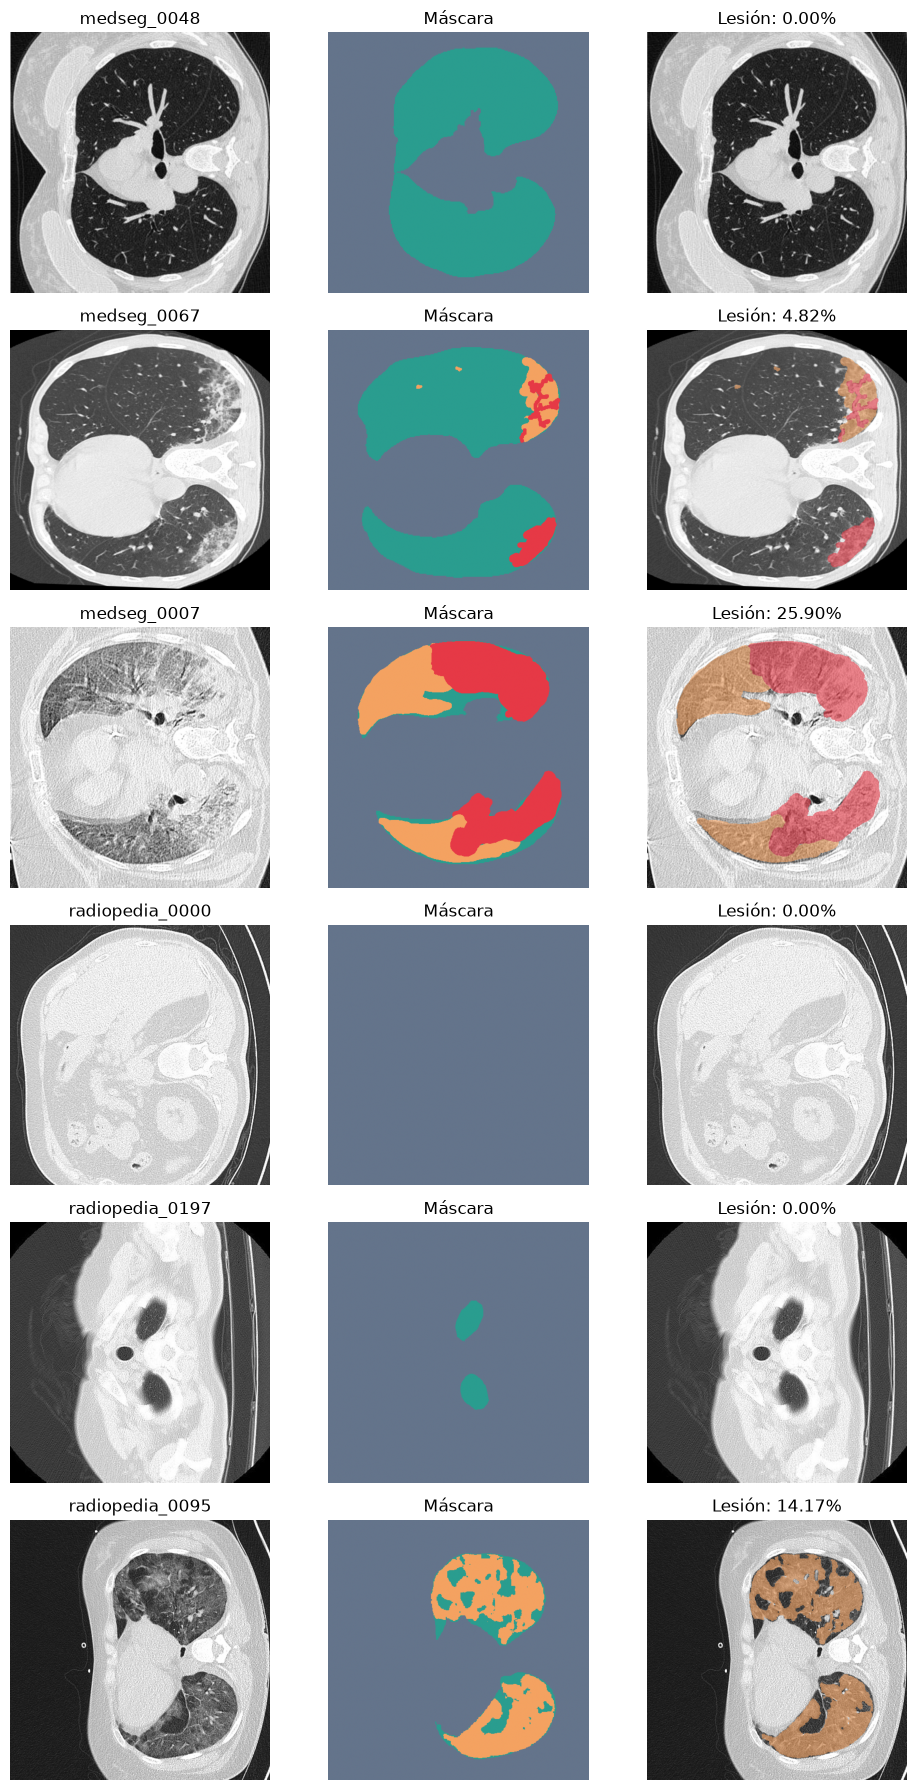

In [ ]:
muestras = []
for fuente, grupo in mascaras_validas[mascaras_validas.imagen_finita].groupby("fuente"):
    ordenados = grupo.sort_values("proporcion_lesion")
    posiciones = np.unique([0, len(ordenados) // 2, len(ordenados) - 1])
    muestras.extend(ordenados.iloc[posiciones].to_dict("records"))

if muestras:
    figura, ejes = plt.subplots(len(muestras), 3, figsize=(10, 3 * len(muestras)), squeeze=False)
    for fila, registro in zip(ejes, muestras):
        imagenes, mascaras = datos[registro["fuente"]]
        imagen = imagenes[registro["indice"], ..., 0]
        etiquetas = mascaras[registro["indice"]].argmax(axis=-1)
        fila[0].imshow(imagen, cmap="gray")
        fila[1].imshow(etiquetas, cmap=ListedColormap(colores), vmin=0, vmax=3)
        fila[2].imshow(imagen, cmap="gray")
        fila[2].imshow(np.ma.masked_where(etiquetas >= 2, etiquetas),
                       cmap=ListedColormap(colores[:2]), vmin=0, vmax=1, alpha=0.6)
        fila[0].set_title(registro["id"])
        fila[1].set_title("Máscara")
        fila[2].set_title(f"Lesión: {registro['proporcion_lesion']:.2%}")
        for eje in fila:
            eje.axis("off")
    plt.tight_layout()
    plt.show()


### Reglas de exclusión y estado final por corte

Decidimos corte por corte, si se **conserva** o se **revisa**
(excluye). Se evalúan, en este orden, los siguientes motivos:

1. **`imagen no finita`**: contiene NaN/Inf.
2. **`imagen constante`**: sin variación de intensidad (`minimo == maximo`).
3. **`máscara inválida`**: no cumple la regla de validez definida anteriormente
   (solo aplica a cortes con máscara, no al set de prueba).
4. **`anotaciones diferentes para la misma imagen`**: la misma imagen (mismo hash)
   aparece en el dataset etiquetado con más de una máscara distinta. Se calcula con
   `groupby("huella_imagen").huella_mascara.nunique() > 1`.
5. **`imagen presente en prueba`**: el hash de una imagen etiquetada coincide con el
   hash de alguna imagen del conjunto de prueba oficial. Esto para
   evitar fuga de información entre entrenamiento y prueba.
6. **`par repetido`**: el par exacto (hash imagen, hash máscara) ya apareció antes en
   el recorrido. Asi que se conserva la primera ocurrencia y se marca para revisión cualquier
   repetición exacta posterior.

El resultado se guarda en dos columnas nuevas: `motivo` (texto concatenado de los
problemas encontrados) y `estado` (`"conservar"` si no hubo ningún motivo, `"revisar"`
en caso contrario). `limpios` es el subconjunto final con `estado == "conservar"`.

In [ ]:
etiquetados = auditoria[auditoria.fuente != "prueba"]
anotaciones = etiquetados.groupby("huella_imagen").huella_mascara.nunique()
conflictos = set(anotaciones[anotaciones > 1].index)
huellas_prueba = set(auditoria.loc[auditoria.fuente == "prueba", "huella_imagen"])

motivos = []
pares_vistos = set()
for registro in auditoria.itertuples():
    problemas = []
    if not registro.imagen_finita:
        problemas.append("imagen no finita")
    if registro.imagen_constante:
        problemas.append("imagen constante")
    if registro.fuente != "prueba":
        if not registro.mascara_valida:
            problemas.append("máscara inválida")
        if registro.huella_imagen in conflictos:
            problemas.append("anotaciones diferentes para la misma imagen")
        if registro.huella_imagen in huellas_prueba:
            problemas.append("imagen presente en prueba")
        par = (registro.huella_imagen, registro.huella_mascara)
        if not problemas:
            if par in pares_vistos:
                problemas.append("par repetido")
            else:
                pares_vistos.add(par)
    motivos.append("; ".join(problemas))

auditoria["motivo"] = motivos
auditoria["estado"] = np.where(auditoria.motivo == "", "conservar", "revisar")
limpios = auditoria[auditoria.estado == "conservar"].copy()
display(pd.crosstab(auditoria.fuente, auditoria.estado))
display(auditoria.loc[auditoria.estado == "revisar", ["id", "motivo"]])


estado,conservar
fuente,
medseg,100
prueba,10
radiopedia,829


,id,motivo


### Verificación post-limpieza

- Se documenta cuantitativamente el efecto de la limpieza, osea, cuántos cortes había por
  fuente originalmente vs. cuántos se conservaron (`balance_limpieza`).
- **Verificaciones explícitas con `assert`** sobre el subconjunto etiquetado limpio
  (`pares_limpios`), que convierten las reglas de la celda anterior en garantías
  comprobadas en vez de solo heurísticas aplicadas una vez:
  1. Quedó al menos un par imagen-máscara válido.
  2. No quedan imágenes duplicadas por hash entre los cortes etiquetados conservados.
  3. Ninguna imagen etiquetada conservada coincide (por hash) con una imagen del
     conjunto de prueba oficial.

Si cualquiera de estas condiciones fallara, la ejecución se detiene aquí en vez de
continuar con un dataset que podria estar contaminado.

In [ ]:
balance_limpieza = auditoria.groupby("fuente").size().to_frame("originales")
balance_limpieza["conservados"] = limpios.groupby("fuente").size().reindex(balance_limpieza.index, fill_value=0)
balance_limpieza["apartados"] = balance_limpieza.originales - balance_limpieza.conservados
display(balance_limpieza)
display(limpios.groupby("fuente")[["media", "desviacion", "proporcion_lesion"]].describe().rename(columns={
    "count": "cantidad", "mean": "promedio", "std": "desviación", "min": "mínimo", "max": "máximo"}))

pares_limpios = limpios[limpios.fuente != "prueba"]
assert len(pares_limpios) > 0, "No quedaron pares válidos"
assert not pares_limpios.huella_imagen.duplicated().any(), "Quedaron imágenes repetidas"
assert not set(pares_limpios.huella_imagen) & huellas_prueba, "Hay coincidencias con la prueba"


,originales,conservados,apartados
fuente,,,
medseg,100,100,0
prueba,10,10,0
radiopedia,829,829,0


media                                                       \
           cantidad  promedio desviación      mínimo       25%       50%   
fuente                                                                     
medseg     100.0000 -443.2362   177.2884 -1,021.4200 -576.3574 -412.8645   
prueba      10.0000 -453.0953   189.3254   -704.4954 -643.7426 -372.2518   
radiopedia 829.0000 -450.6814    96.2648   -649.9664 -520.5753 -474.9098   

                               desviacion           ...                    \
                 75%    máximo   cantidad promedio  ...      75%   máximo   
fuente                                              ...                     
medseg     -325.8640 -123.8465   100.0000 456.3977  ... 499.3177 604.8113   
prueba     -349.3478 -160.2301    10.0000 471.2789  ... 474.6914 574.6290   
radiopedia -397.1802 -105.6649   829.0000 485.2760  ... 498.2045 534.9848   

           proporcion_lesion                                                  \
                    cantidad promedio desviación mínimo    25%    50%    75%   
fuente                                                                         
medseg              100.0000   0.0681     0.0608 0.0000 0.0246 0.0473 0.0942   
prueba                0.0000      NaN        NaN    NaN    NaN    NaN    NaN   
radiopedia          829.0000   0.0125     0.0275 0.0000 0.0000 0.0000 0.0126   

                   
           máximo  
fuente             
medseg     0.2590  
prueba        NaN  
radiopedia 0.1417  

[3 rows x 24 columns]

### Definición de transformar

Esta celda define la función que se aplicará a cada corte conservado, y previsualiza
su efecto sobre el corte con mayor proporción de lesion.

**Transformación de la imagen:**
1. Conversión a `float64` antes de empezar, para evitar perdida de precisión durante
   la normalización.
2. Normalización min-max por imagen individual: `(imagen - imagen.min()) / (imagen.max() - imagen.min())`.
   Cada corte se reescala a su propio rango [0,1], adecuado dado que las imágenes
   crudas vienen en escalas muy distintas.
3. Conversión a `float32` tras normalizar, para reducir el tamaño de almacenamiento
   a la mitad respecto al `float64` original.
4. Redimensionamiento a 256×256 con interpolación bilineal
5. **`np.clip(imagen, 0, 1)`** después del resize para corrigir el posible overshoot que
   puede introducir la interpolación bilineal en bordes de alto contraste, garantizando
   que nuestro rango final quede acotado en [0,1].
6. Expansión de dimensión de canal (`[..., None]`) para dejar la forma final en
   `(256, 256, 1)`.

**Transformación de la máscara:**
1. Conversión a `uint8` con copia, para no alterar el arreglo `bool` original.
2. Recalculamos el canal de fondo como el complemento logico de los tres
   canales de lesión (`mascara[...,3] = ~mascara[...,:3].any(axis=-1)`). Esto para que el fondo nunca se tome del dato asi en crudo y siempre se derive de las otras tres clases.
3. Redimensionamiento a 256×256, aplicado canal por
   canal. Se usa nearest-neighbor porque la máscara es categórica
   (0/1 por clase).
4. No se normaliza la máscara y la mantenemos en 0/1 `uint8`, pues representa
   presencia/ausencia de clase, no una magnitud continua.

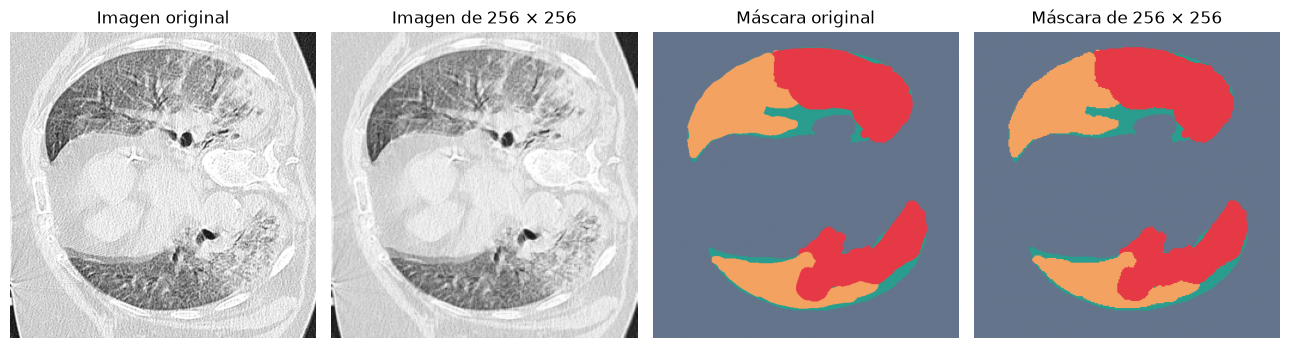

In [ ]:
def transformar(imagen, mascara=None):
    imagen = imagen.astype(np.float64)
    imagen = ((imagen - imagen.min()) / (imagen.max() - imagen.min())).astype(np.float32)
    imagen = np.asarray(Image.fromarray(imagen).resize(tamano, Image.Resampling.BILINEAR))
    imagen = np.clip(imagen, 0, 1)[..., None]
    if mascara is not None:
        mascara = mascara.astype(np.uint8).copy()
        mascara[..., 3] = ~mascara[..., :3].any(axis=-1)
        mascara = np.stack([
            np.asarray(Image.fromarray(mascara[..., clase].astype(np.uint8)).resize(
                tamano, Image.Resampling.NEAREST)) for clase in range(4)
        ], axis=-1)
    return imagen, mascara

registro = pares_limpios.sort_values("proporcion_lesion", ascending=False).iloc[0]
imagenes, mascaras = datos[registro.fuente]
imagen_original = imagenes[int(registro.indice), ..., 0]
mascara_original = mascaras[int(registro.indice)]
imagen_nueva, mascara_nueva = transformar(imagen_original, mascara_original)

figura, ejes = plt.subplots(1, 4, figsize=(13, 4))
ejes[0].imshow(imagen_original, cmap="gray")
ejes[1].imshow(imagen_nueva[..., 0], cmap="gray", vmin=0, vmax=1)
ejes[2].imshow(mascara_original.argmax(-1), cmap=ListedColormap(colores), vmin=0, vmax=3)
ejes[3].imshow(mascara_nueva.argmax(-1), cmap=ListedColormap(colores), vmin=0, vmax=3)
for eje, titulo in zip(ejes, ["Imagen original", "Imagen de 256 × 256", "Máscara original", "Máscara de 256 × 256"]):
    eje.set_title(titulo)
    eje.axis("off")
plt.tight_layout()
plt.show()


### Aplicación, guardado y metadatos derivados

- Se aplica `transformar` a **todos** los cortes en `limpios` que ya esten filtrados, y se
  guarda cada corte como un `.npz` comprimido independiente. Si el corte no tiene
  máscara, se guarda solo la imagen.
- **`particion`**: se marca `"prueba oficial"` para cortes sin máscara, o
  `"pendiente de identificar pacientes"` para los que sí tienen máscara. Como el dataset que estamos usando no trae id de paciente, no se asume un split
  train/validación aleatorio a nivel de corte y se deja marcado como pendiente en vez de decidirlo
  arbitrariamente ahorita.
- **`proporcion_final_{clase}`**: proporción de píxeles por clase recalculada
  despues del resize, para poder comparar contra la proporción
  original y ver cuánto cambia la cobertura de cada clase por el redimensionamiento.
- **`pierde_clase_lesion`**: se marca `True` si alguna clase de lesión (0 o 1) tenía
  proporción > 0 antes del resize pero termina con 0 píxeles después de él , osea,
  detecta si el downsampling mas el nearest-neighbor hizo desaparecer por completo una
  lesión pequeña. No provoca descarte del corte, solo lo señala para revisión posterior.
- Guardamos tambien `auditoria.csv`, `inventario.csv`, `manifiesto.csv` y
  `balance_limpieza.csv` para llevar un registro de todas las decisiones anteriores.

In [ ]:
salida.mkdir(parents=True, exist_ok=False)
resultados = []
for registro in limpios.itertuples(index=False):
    imagenes, mascaras = datos[registro.fuente]
    imagen = imagenes[registro.indice, ..., 0]
    mascara = mascaras[registro.indice] if mascaras is not None else None
    imagen, mascara = transformar(imagen, mascara)
    archivo = f"{registro.id}.npz"
    if mascara is None:
        np.savez_compressed(salida / archivo, imagen=imagen)
    else:
        np.savez_compressed(salida / archivo, imagen=imagen, mascara=mascara)
    resultado = registro._asdict()
    resultado["archivo"] = archivo
    resultado["particion"] = "prueba oficial" if mascara is None else "pendiente de identificar pacientes"
    for clase in range(4):
        resultado[f"proporcion_final_{clase}"] = float(mascara[..., clase].mean()) if mascara is not None else np.nan
    resultado["pierde_clase_lesion"] = bool(mascara is not None and any(
        resultado[f"proporcion_{clase}"] > 0 and mascara[..., clase].sum() == 0 for clase in (0, 1)))
    resultados.append(resultado)

manifiesto = pd.DataFrame(resultados)
auditoria.to_csv(salida / "auditoria.csv", index=False)
inventario.to_csv(salida / "inventario.csv", index=False)
manifiesto.to_csv(salida / "manifiesto.csv", index=False)
balance_limpieza.to_csv(salida / "balance_limpieza.csv")
print("Carpeta de resultados:", salida)


Carpeta de resultados: /Users/facundo/Projects/personal/advanced-AI/mini-reto/data/processed/20260909_190152_539384


### Verificación final

Cada archivo `.npz` generado se vuelve a abrir desde disco y se verifica con `assert`
que las decisiones de transformación se cumplieron realmente en el archivo final:

- Imagen: forma exacta `(256, 256, 1)`, tipo `float32`, todos los valores finitos y
  dentro de `[0, 1]`.
- Máscara (cuando existe): forma exacta `(256, 256, 4)`, tipo `uint8`, todos los
  valores en `{0, 1}`, y suma de los 4 canales igual a 1 en cada píxel. Esto para confirmar que la corrección del canal de fondo dejó cada píxel
  con exactamente una clase asignada.
- Para el set de prueba, se confirma que el `.npz` contiene únicamente la clave
  `"imagen"` sin la mascara.
- Se calcula `cambio_cobertura.csv`: diferencia en puntos porcentuales entre la
  proporción de cada clase antes y despues de la transformación, para ver el
  efecto del resize sobre el balance de clases.
- `resumen.json` consolida las cifras clave de todo el proceso de limpieza y
  transformación (cortes originales, conservados, apartados, máscaras de fondo
  corregidas, píxeles corregidos, cortes sin lesión, cortes que pierden alguna clase).

In [ ]:
for registro in manifiesto.itertuples():
    with np.load(salida / registro.archivo, allow_pickle=False) as archivo:
        imagen = archivo["imagen"]
        assert imagen.shape == (256, 256, 1)
        assert imagen.dtype == np.float32
        assert np.isfinite(imagen).all() and 0 <= imagen.min() <= imagen.max() <= 1
        if registro.fuente != "prueba":
            mascara = archivo["mascara"]
            assert mascara.shape == (256, 256, 4) and mascara.dtype == np.uint8
            assert np.isin(mascara, [0, 1]).all() and (mascara.sum(axis=-1) == 1).all()
        else:
            assert archivo.files == ["imagen"]
assert len(list(salida.glob("*.npz"))) == len(limpios)

cambios = pd.DataFrame({clases[clase]:
    (manifiesto[f"proporcion_final_{clase}"] - manifiesto[f"proporcion_{clase}"]) * 100
    for clase in range(4)})
display(cambios.agg(["mean", "min", "max"]).rename(index={"mean": "promedio", "min": "mínimo", "max": "máximo"}))
cambios.to_csv(salida / "cambio_cobertura.csv", index=False)
resumen = pd.Series({
    "Cortes originales": len(auditoria),
    "Cortes etiquetados conservados": len(pares_limpios),
    "Cortes de prueba conservados": int((limpios.fuente == "prueba").sum()),
    "Cortes apartados": int((auditoria.estado == "revisar").sum()),
    "Máscaras con fondo corregido": int((limpios.pixeles_fondo_inconsistente > 0).sum()),
    "Píxeles de fondo corregidos": int(limpios.pixeles_fondo_inconsistente.sum()),
    "Cortes conservados sin lesión": int((pares_limpios.proporcion_lesion == 0).sum()),
    "Cortes que pierden alguna clase de lesión": int(manifiesto.pierde_clase_lesion.sum()),
}, name="Cantidad")
resumen.to_json(salida / "resumen.json", force_ascii=False, indent=2)
display(resumen)
print("Verificación de archivos completada")


,Vidrio esmerilado,Consolidación,Otros tejidos pulmonares,Fondo
promedio,0.0002,-0.0001,0.0031,-0.0124
mínimo,-0.0530,-0.0294,-0.1217,-0.4353
máximo,0.0351,0.0240,0.1774,0.1240


Cortes originales                              939
Cortes etiquetados conservados                 929
Cortes de prueba conservados                    10
Cortes apartados                                 0
Máscaras con fondo corregido                   279
Píxeles de fondo corregidos                  22537
Cortes conservados sin lesión                  458
Cortes que pierden alguna clase de lesión        5
Name: Cantidad, dtype: int64

Verificación de archivos completada
